In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\archive (1)\fmcg_sales_3years_1M_rows.csv")

In [4]:
df.head()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,...,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,...,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,...,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,...,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,...,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073


In [5]:
df.columns.tolist()

['date',
 'year',
 'month',
 'day',
 'weekofyear',
 'weekday',
 'is_weekend',
 'is_holiday',
 'temperature',
 'rain_mm',
 'store_id',
 'country',
 'city',
 'channel',
 'latitude',
 'longitude',
 'sku_id',
 'sku_name',
 'category',
 'subcategory',
 'brand',
 'units_sold',
 'list_price',
 'discount_pct',
 'promo_flag',
 'gross_sales',
 'net_sales',
 'stock_on_hand',
 'stock_out_flag',
 'lead_time_days',
 'supplier_id',
 'purchase_cost',
 'margin_pct']

In [6]:
print(df['country'].unique())
print(df['category'].unique())
print(df['channel'].unique())
print(df.groupby('sku_id')['sku_name'].first())
print(df['store_id'].nunique,"stores")

<StringArray>
['Germany', 'Italy', 'Poland', 'France', 'Spain', 'Austria', 'Netherlands']
Length: 7, dtype: str
<StringArray>
['Personal Care', 'Beverages', 'Dairy', 'Snacks', 'Home Care']
Length: 5, dtype: str
<StringArray>
['Hypermarket', 'Supermarket', 'E-commerce', 'Convenience']
Length: 4, dtype: str
sku_id
SKU0001          BrandA Soda
SKU0002          BrandB Soda
SKU0003          BrandC Soda
SKU0004          BrandD Soda
SKU0005          BrandE Soda
                 ...        
SKU0098    BrandB Toothpaste
SKU0099    BrandC Toothpaste
SKU0100    BrandD Toothpaste
SKU0101    BrandE Toothpaste
SKU0102    BrandF Toothpaste
Name: sku_name, Length: 102, dtype: str
<bound method IndexOpsMixin.nunique of 0          STORE0001
1          STORE0001
2          STORE0001
3          STORE0001
4          STORE0001
             ...    
1099995    STORE0013
1099996    STORE0013
1099997    STORE0013
1099998    STORE0013
1099999    STORE0013
Name: store_id, Length: 1100000, dtype: str> stores


In [7]:
beverages=df[df['category']=='Beverages']
print(beverages[['sku_id','sku_name','brand','subcategory']].drop_duplicates())

         sku_id             sku_name   brand   subcategory
1095    SKU0016         BrandD Water  BrandD         Water
4380    SKU0006          BrandF Soda  BrandF          Soda
7665    SKU0008         BrandB Juice  BrandB         Juice
9855    SKU0018         BrandF Water  BrandF         Water
16425   SKU0020  BrandB Energy drink  BrandB  Energy drink
17520   SKU0004          BrandD Soda  BrandD          Soda
20805   SKU0014         BrandB Water  BrandB         Water
26280   SKU0015         BrandC Water  BrandC         Water
29565   SKU0012         BrandF Juice  BrandF         Juice
36135   SKU0024  BrandF Energy drink  BrandF  Energy drink
47085   SKU0011         BrandE Juice  BrandE         Juice
52560   SKU0007         BrandA Juice  BrandA         Juice
54750   SKU0001          BrandA Soda  BrandA          Soda
64605   SKU0023  BrandE Energy drink  BrandE  Energy drink
67890   SKU0010         BrandD Juice  BrandD         Juice
71175   SKU0002          BrandB Soda  BrandB          So

In [26]:
germany_bev=df[(df['country']=='Germany') & (df['category']=='Beverages')]
summary=germany_bev.groupby('sku_id').agg(
    sku_name=('sku_name','first'),
    avg_stockout_rate=('stock_out_flag','mean'),
    avg_lead_time=('lead_time_days','mean'),
    total_units_sold=('units_sold','sum'),
    avg_margin=('margin_pct','mean')
).sort_values('avg_stockout_rate',ascending=False)
print(summary)

                    sku_name  avg_stockout_rate  avg_lead_time  \
sku_id                                                           
SKU0010         BrandD Juice           0.043836       6.410046   
SKU0013         BrandA Water           0.035616       6.610959   
SKU0012         BrandF Juice           0.033790       6.522831   
SKU0007         BrandA Juice           0.033333       6.534247   
SKU0023  BrandE Energy drink           0.032420       6.479452   
SKU0020  BrandB Energy drink           0.032420       6.426941   
SKU0021  BrandC Energy drink           0.031963       6.622831   
SKU0017         BrandE Water           0.031507       6.449772   
SKU0006          BrandF Soda           0.031050       6.503196   
SKU0018         BrandF Water           0.030137       6.474886   
SKU0016         BrandD Water           0.030137       6.562557   
SKU0005          BrandE Soda           0.030137       6.476712   
SKU0002          BrandB Soda           0.029680       6.489954   
SKU0015   

In [27]:
summary['stockout_rank']=summary['avg_stockout_rate'].rank(ascending=False)
summary['lead_time_rank']=summary['avg_lead_time'].rank(ascending=False)
summary['volume_rank']=summary['total_units_sold'].rank(ascending=False)
summary['composite_risk_score']=summary[['stockout_rank','lead_time_rank','volume_rank']].mean(axis=1)
print(summary.sort_values('composite_risk_score').head())

                    sku_name  avg_stockout_rate  avg_lead_time  \
sku_id                                                           
SKU0013         BrandA Water           0.035616       6.610959   
SKU0021  BrandC Energy drink           0.031963       6.622831   
SKU0001          BrandA Soda           0.028311       6.565753   
SKU0012         BrandF Juice           0.033790       6.522831   
SKU0023  BrandE Energy drink           0.032420       6.479452   

         total_units_sold  avg_margin  stockout_rank  lead_time_rank  \
sku_id                                                                 
SKU0013            134285    0.362339            2.0             2.0   
SKU0021            150894    0.401435            7.0             1.0   
SKU0001            320304    0.362895           16.5             3.0   
SKU0012            134884    0.363429            3.0             9.0   
SKU0023            227177    0.366711            5.5            17.0   

         volume_rank  composite_

In [28]:
skus_of_interest=['SKU0013','SKU001','SKU007']
project_df=germany_bev[germany_bev['sku_id'].isin(skus_of_interest)].copy()
project_df['date']=pd.to_datetime(project_df['date'])
print(project_df.shape)
project_df.head()

(1095, 33)


,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
281415,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,...,0.0,0,900.36,900.36,209,0,2,S030,5.00,0.322
281416,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,...,0.0,0,332.10,332.10,294,0,2,S028,5.13,0.305
281417,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,...,0.0,0,560.88,560.88,291,0,7,S036,4.96,0.328
281418,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,...,0.0,0,715.86,715.86,268,0,9,S049,4.01,0.456
281419,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,...,0.3,1,1719.54,1203.68,215,0,10,S044,5.16,0.000


IndexError: single positional indexer is out-of-bounds

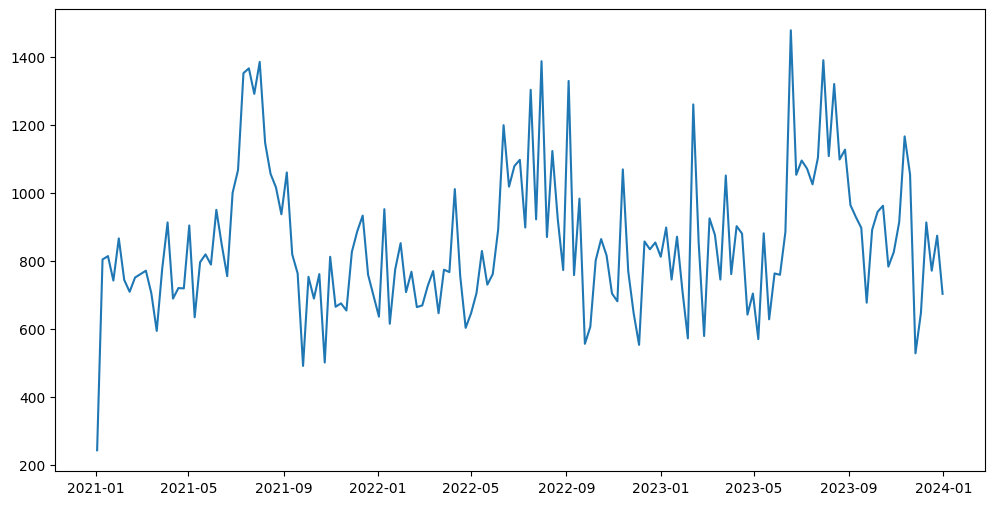

In [29]:
weekly=project_df.groupby(['sku_id','sku_name',pd.Grouper(key='date',freq='W')])['units_sold'].sum().reset_index()
fig,ax=plt.subplots(figsize=(12,6))
for sku in skus_of_interest:
    data=weekly[weekly['sku_id']==sku]
    ax.plot(data['date'],data['units_sold'],label=data['sku_name'].iloc[0])
ax.set_title("weekly demand-germany beverages(3 SKU comparison)")
ax.set_xlabel('week')
ax.set_ylabel('units_sold')
ax.legend()
plt.show()

debugging-

In [ ]:
print(weekly['sku_id'].unique())
print(weekly.shape)

<StringArray>
['SKU0013']
Length: 1, dtype: str
(157, 4)


In [ ]:
print(skus_of_interest)

['SKU0013', 'SKU001', 'SKU007']


In [ ]:
print(project_df['sku_id'].unique())

<StringArray>
['SKU0013']
Length: 1, dtype: str


In [30]:
print(df.shape)
print(df['sku_id'].nunique())
print(df['category'].unique())

(1100000, 33)
102
<StringArray>
['Personal Care', 'Beverages', 'Dairy', 'Snacks', 'Home Care']
Length: 5, dtype: str


In [31]:
print(df[df['sku_id'] == 'SKU0001'].shape)
print(df[df['sku_id'] == 'SKU0007'].shape)
print(df[df['sku_id'] == 'SKU0013'].shape)

(14235, 33)
(10950, 33)
(10950, 33)


In [32]:
print(df[(df['sku_id'] == 'SKU0001') & (df['country'] == 'Germany')].shape)
print(df[(df['sku_id'] == 'SKU0007') & (df['country'] == 'Germany')].shape)
print(df[(df['sku_id'] == 'SKU0013') & (df['country'] == 'Germany')].shape)


(2190, 33)
(2190, 33)
(1095, 33)


In [33]:
germany_bev = df[(df['country'] == 'Germany') & (df['category'] == 'Beverages')]
print(germany_bev.shape)
print(germany_bev['sku_id'].unique())

(40515, 33)
<StringArray>
['SKU0016', 'SKU0006', 'SKU0008', 'SKU0018', 'SKU0020', 'SKU0004', 'SKU0014',
 'SKU0015', 'SKU0012', 'SKU0024', 'SKU0011', 'SKU0007', 'SKU0001', 'SKU0023',
 'SKU0010', 'SKU0002', 'SKU0019', 'SKU0017', 'SKU0021', 'SKU0009', 'SKU0013',
 'SKU0005', 'SKU0003']
Length: 23, dtype: str


In [34]:
skus_of_interest = ['SKU0013', 'SKU0001', 'SKU0007']

project_df = germany_bev[germany_bev['sku_id'].isin(skus_of_interest)].copy()
project_df['date'] = pd.to_datetime(project_df['date'])

print(project_df['sku_id'].unique())
print(project_df.shape)

<StringArray>
['SKU0007', 'SKU0001', 'SKU0013']
Length: 3, dtype: str
(5475, 33)


<StringArray>
['SKU0001', 'SKU0007', 'SKU0013']
Length: 3, dtype: str


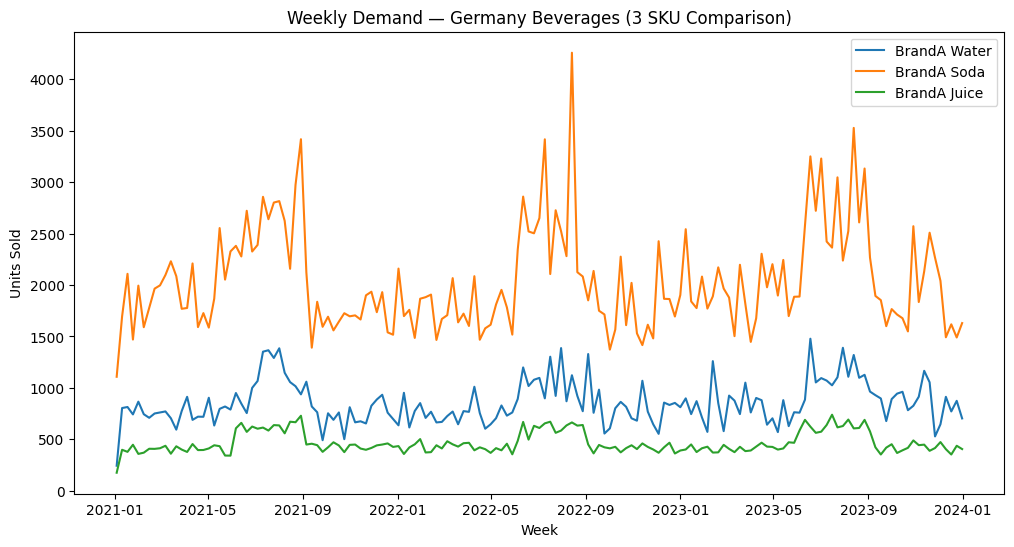

In [35]:
weekly = project_df.groupby(['sku_id', 'sku_name', pd.Grouper(key='date', freq='W')])['units_sold'].sum().reset_index()

print(weekly['sku_id'].unique())  # sanity check before plotting

fig, ax = plt.subplots(figsize=(12, 6))
for sku in skus_of_interest:
    data = weekly[weekly['sku_id'] == sku]
    ax.plot(data['date'], data['units_sold'], label=data['sku_name'].iloc[0])

ax.set_title('Weekly Demand — Germany Beverages (3 SKU Comparison)')
ax.set_xlabel('Week')
ax.set_ylabel('Units Sold')
ax.legend()
plt.show()

In [40]:
stockout_weekly=project_df.groupby(['sku_id','sku_name',pd.Grouper(key='date',freq='W')])['stock_out_flag'].mean().reset_index()


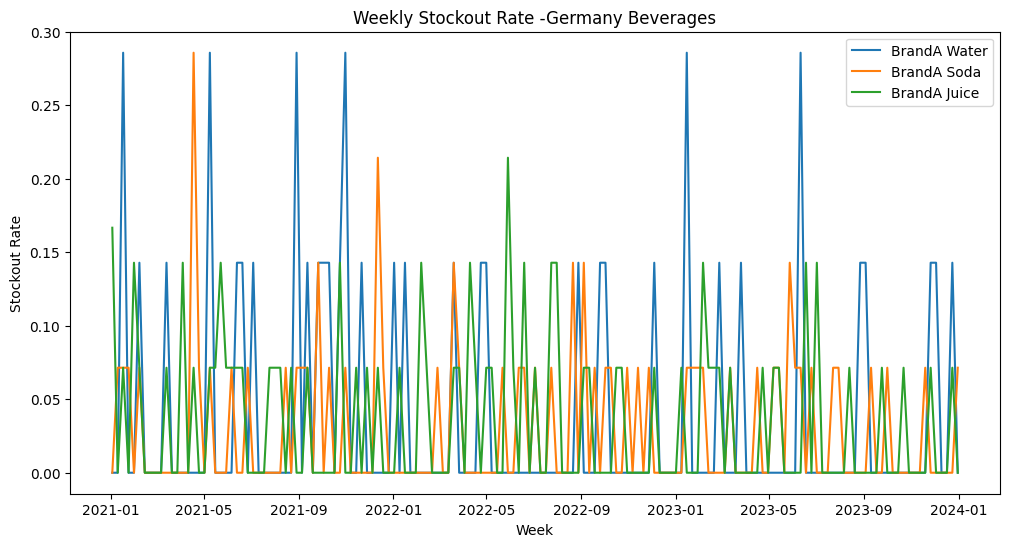

In [41]:
fig,ax=plt.subplots(figsize=(12,6))
for sku in skus_of_interest:
    data=stockout_weekly[stockout_weekly['sku_id']==sku]
    ax.plot(data['date'],data['stock_out_flag'],label=data['sku_name'].iloc[0])
ax.set_title('Weekly Stockout Rate -Germany Beverages')
ax.set_xlabel('Week')
ax.set_ylabel('Stockout Rate')
ax.legend()
plt.show()

In [43]:
water_demand=weekly[weekly['sku_id']=='SKU0013'][['date','units_sold']]
water_stockout=stockout_weekly[stockout_weekly['sku_id']=='SKU0013'][['date','stock_out_flag']]
water_combined=water_demand.merge(water_stockout,on='date')
correlation=water_combined['units_sold'].corr(water_combined['stock_out_flag'])
print(f"Correlation between demand and stockout rate for Water: {correlation:.3f}")

Correlation between demand and stockout rate for Water: -0.256


In [44]:
water_data=project_df[project_df['sku_id']=='SKU0013']
print(water_data['lead_time_days'].describe())
print()
print(
    water_data.groupby('supplier_id').agg(
        stockout_rate=('stock_out_flag','mean'),
        avg_lead_time=('lead_time_days','mean'),
        order_count=('supplier_id','count'),
        avg_purchases=('purchase_cost','mean')
    ).sort_values('stockout_rate',ascending=False)
)

count    1095.000000
mean        6.610959
std         2.106026
min         1.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        13.000000
Name: lead_time_days, dtype: float64

             stockout_rate  avg_lead_time  order_count  avg_purchases
supplier_id                                                          
S033              0.166667       7.333333           12       4.170833
S059              0.142857       6.619048           21       4.270476
S035              0.125000       6.187500           16       4.578750
S053              0.117647       6.470588           17       4.394118
S047              0.111111       7.111111           18       4.396111
S013              0.105263       7.210526           19       4.471053
S046              0.095238       6.714286           21       4.394286
S019              0.095238       6.714286           21       4.323333
S039              0.090909       6.590909           22       4.343182
S009              0.0869

In [45]:
print(water_data.groupby('channel')['stock_out_flag'].agg(['mean','count']))
print()
print(water_data.groupby('store_id')['stock_out_flag'].agg(['mean','count']))

                 mean  count
channel                     
Hypermarket  0.035616   1095

               mean  count
store_id                  
STORE0004  0.035616   1095


In [46]:
import numpy as np

baseline_rate = water_data['stock_out_flag'].mean()

supplier_summary = water_data.groupby('supplier_id').agg(
    stockout_rate=('stock_out_flag', 'mean'),
    order_count=('supplier_id', 'count')
)

supplier_summary['standard_error'] = np.sqrt(baseline_rate * (1 - baseline_rate) / supplier_summary['order_count'])
supplier_summary['z_score'] = (supplier_summary['stockout_rate'] - baseline_rate) / supplier_summary['standard_error']

# z_score > 2 or < -2 means "statistically unusual, not likely random noise"
flagged = supplier_summary[abs(supplier_summary['z_score']) > 2].sort_values('z_score', ascending=False)
print(flagged)

             stockout_rate  order_count  standard_error   z_score
supplier_id                                                      
S059              0.142857           21        0.040443  2.651668
S033              0.166667           12        0.053501  2.449505


In [47]:
corr_lt_stockout = water_data['lead_time_days'].corr(water_data['stock_out_flag'])
print(f"Correlation between lead time and stockout: {corr_lt_stockout:.3f}")

water_data['lead_time_bucket'] = pd.cut(water_data['lead_time_days'], bins=[0,5,7,9,15], labels=['1-5d','6-7d','8-9d','10+d'])
print(water_data.groupby('lead_time_bucket', observed=True)['stock_out_flag'].agg(['mean','count']))

Correlation between lead time and stockout: 0.017
                      mean  count
lead_time_bucket                 
1-5d              0.033951    324
6-7d              0.039702    403
8-9d              0.024911    281
10+d              0.057471     87


In [48]:
# Does promo activity or discounting correlate with stockouts?
print(water_data.groupby('promo_flag')['stock_out_flag'].agg(['mean', 'count']))
print()
corr_discount = water_data['discount_pct'].corr(water_data['stock_out_flag'])
print(f"Correlation between discount_pct and stockout: {corr_discount:.3f}")
print()

# Weekend/holiday effects
print(water_data.groupby('is_weekend')['stock_out_flag'].agg(['mean', 'count']))
print(water_data.groupby('is_holiday')['stock_out_flag'].agg(['mean', 'count']))

                mean  count
promo_flag                 
0           0.037671    876
1           0.027397    219

Correlation between discount_pct and stockout: -0.019

                mean  count
is_weekend                 
0           0.038412    781
1           0.028662    314
                mean  count
is_holiday                 
0           0.036111   1080
1           0.000000     15


In [49]:
print(water_data.groupby('stock_out_flag')['stock_on_hand'].describe())

                 count        mean        std   min     25%    50%    75%  \
stock_out_flag                                                              
0               1056.0  300.943182  80.687911   0.0  244.75  299.0  355.0   
1                 39.0  277.358974  69.579749  74.0  232.00  278.0  322.0   

                  max  
stock_out_flag         
0               545.0  
1               399.0  


In [50]:
from scipy import stats

stocked_out = water_data[water_data['stock_out_flag'] == 1]['stock_on_hand']
not_stocked_out = water_data[water_data['stock_out_flag'] == 0]['stock_on_hand']

t_stat, p_value = stats.ttest_ind(stocked_out, not_stocked_out, equal_var=False)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")

t-statistic: -2.066, p-value: 0.0450


In [51]:
# Compare units_sold on stockout days vs. non-stockout days as a proxy for demand suppression
print(water_data.groupby('stock_out_flag')['units_sold'].describe())

                 count        mean        std   min   25%    50%    75%    max
stock_out_flag                                                                
0               1056.0  126.120265  57.737958  21.0  88.0  114.0  154.0  453.0
1                 39.0   28.256410  28.707892   0.0   9.5   20.0   34.5  143.0


In [52]:
avg_price = water_data['list_price'].mean() if 'list_price' in water_data.columns else water_data['purchase_cost'].mean() / (1 - water_data['margin_pct'].mean())
avg_margin_pct = water_data['margin_pct'].mean()
avg_purchase_cost = water_data['purchase_cost'].mean()

# Estimate typical daily demand (from non-stockout days) as the "should have sold" baseline
normal_daily_demand = water_data[water_data['stock_out_flag'] == 0]['units_sold'].mean()
actual_stockout_day_sales = water_data[water_data['stock_out_flag'] == 1]['units_sold'].mean()

lost_units_per_stockout_day = normal_daily_demand - actual_stockout_day_sales
num_stockout_days = water_data['stock_out_flag'].sum()
total_lost_units = lost_units_per_stockout_day * num_stockout_days

print(f"Estimated lost units per stockout day: {lost_units_per_stockout_day:.1f}")
print(f"Number of stockout days observed: {num_stockout_days}")
print(f"Total estimated lost units (observed period): {total_lost_units:.0f}")

# Financial impact — using margin, since that's the actual profit lost, not just revenue
lost_margin_per_unit = avg_purchase_cost * (avg_margin_pct / (1 - avg_margin_pct))  # rough margin-per-unit estimate
total_lost_margin = total_lost_units * lost_margin_per_unit
print(f"Estimated lost margin (observed period): €{total_lost_margin:.0f}")

Estimated lost units per stockout day: 97.9
Number of stockout days observed: 39
Total estimated lost units (observed period): 3817
Estimated lost margin (observed period): €9601


In [53]:
buffer_increase = not_stocked_out.mean() - stocked_out.mean()  # the ~24 unit gap from before
cost_of_extra_buffer = buffer_increase * avg_purchase_cost  # one-time inventory carrying cost, not recurring
print(f"Recommended buffer increase: {buffer_increase:.0f} units")
print(f"One-time cost to hold extra buffer: €{cost_of_extra_buffer:.2f}")

Recommended buffer increase: 24 units
One-time cost to hold extra buffer: €104.40


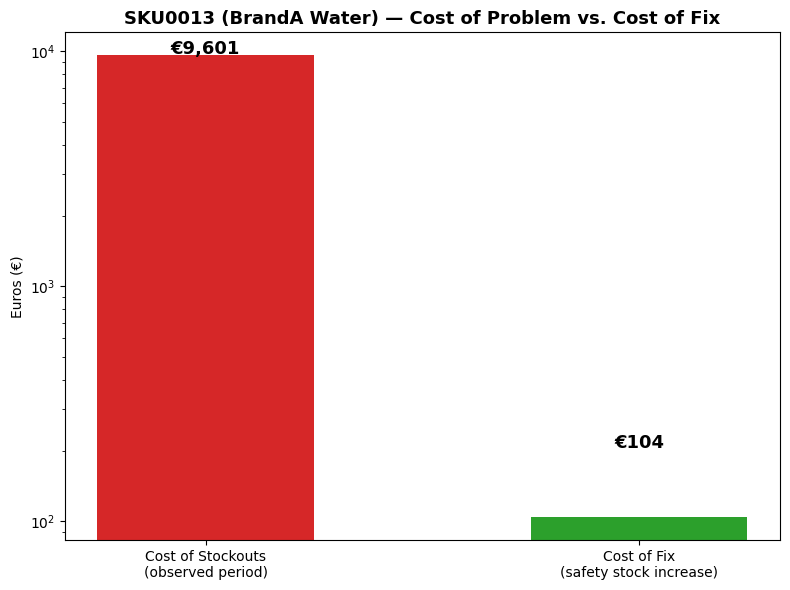

In [54]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
categories = ['Cost of Stockouts\n(observed period)', 'Cost of Fix\n(safety stock increase)']
values = [9601, 104.40]
colors = ['#d62728', '#2ca02c']  # red for the problem, green for the cheap fix

bars = ax.bar(categories, values, color=colors, width=0.5)

# Add value labels on top of bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'€{val:,.0f}', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Euros (€)')
ax.set_title('SKU0013 (BrandA Water) — Cost of Problem vs. Cost of Fix', fontsize=13, fontweight='bold')
ax.set_yscale('log')  # log scale so the small green bar is still visible next to the large red one
plt.tight_layout()
plt.savefig('cost_comparison.png', dpi=150)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_33556\3032647183.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Non-Stockout Days', 'Stockout Days'], patch_artist=True)


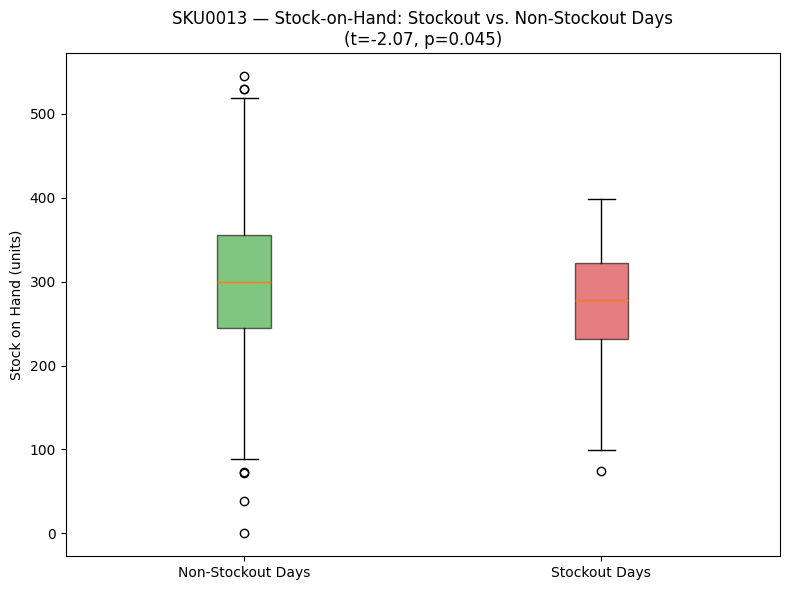

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))
data_to_plot = [not_stocked_out, stocked_out]
bp = ax.boxplot(data_to_plot, labels=['Non-Stockout Days', 'Stockout Days'], patch_artist=True)

colors = ['#2ca02c', '#d62728']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Stock on Hand (units)')
ax.set_title('SKU0013 — Stock-on-Hand: Stockout vs. Non-Stockout Days\n(t=-2.07, p=0.045)', fontsize=12)
plt.tight_layout()
plt.savefig('stock_comparison.png', dpi=150)
plt.show()

In [56]:
def analyze_sku_buffer(sku_id, sku_label):
    sku_data = project_df[project_df['sku_id'] == sku_id]
    
    stocked_out = sku_data[sku_data['stock_out_flag'] == 1]['stock_on_hand']
    not_stocked_out = sku_data[sku_data['stock_out_flag'] == 0]['stock_on_hand']
    
    print(f"--- {sku_label} ({sku_id}) ---")
    print(f"Stockout events: {len(stocked_out)} / {len(sku_data)} total days")
    print(f"Avg stock_on_hand — stockout days: {stocked_out.mean():.1f}")
    print(f"Avg stock_on_hand — non-stockout days: {not_stocked_out.mean():.1f}")
    
    if len(stocked_out) >= 2:  # t-test needs at least 2 data points
        t_stat, p_value = stats.ttest_ind(stocked_out, not_stocked_out, equal_var=False)
        print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
    else:
        print("Too few stockout events for a meaningful t-test")
    print()

analyze_sku_buffer('SKU0001', 'BrandA Soda (benchmark)')
analyze_sku_buffer('SKU0007', 'BrandA Juice (margin priority)')

--- BrandA Soda (benchmark) (SKU0001) ---
Stockout events: 62 / 2190 total days
Avg stock_on_hand — stockout days: 279.4
Avg stock_on_hand — non-stockout days: 299.6
t-statistic: -1.651, p-value: 0.1036

--- BrandA Juice (margin priority) (SKU0007) ---
Stockout events: 73 / 2190 total days
Avg stock_on_hand — stockout days: 306.0
Avg stock_on_hand — non-stockout days: 301.4
t-statistic: 0.481, p-value: 0.6318



In [57]:
import statsmodels.api as sm

# Build the feature set for SKU0013
model_data = water_data[['stock_out_flag', 'lead_time_days', 'stock_on_hand', 
                          'promo_flag', 'temperature', 'is_weekend', 'discount_pct']].copy()

model_data = model_data.dropna()

X = model_data[['lead_time_days', 'stock_on_hand', 'promo_flag', 'temperature', 'is_weekend', 'discount_pct']]
y = model_data['stock_out_flag']

X = sm.add_constant(X)  # adds intercept term

logit_model = sm.Logit(y, X)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.151594
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         stock_out_flag   No. Observations:                 1095
Model:                          Logit   Df Residuals:                     1088
Method:                           MLE   Df Model:                            6
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                 0.01405
Time:                        13:07:05   Log-Likelihood:                -166.00
converged:                       True   LL-Null:                       -168.36
Covariance Type:            nonrobust   LLR p-value:                    0.5790
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.3740      1.013     -2.343      0.019      -4.359      -0.388
lead_time_days   

In [63]:
water_data_copy = water_data.copy()
buffer_boost = 24  # your recommended increase

# For stockout days only, simulate the boosted stock level
stockout_days = water_data_copy[water_data_copy['stock_out_flag'] == 1].copy()
stockout_days['simulated_stock'] = stockout_days['stock_on_hand'] + buffer_boost

# Use normal-day average demand as the "true demand" proxy — NOT actual units_sold,
# since units_sold on a stockout day is artificially capped by the stockout itself
normal_daily_demand = water_data[water_data['stock_out_flag'] == 0]['units_sold'].mean()

stockout_days['would_avoid_stockout'] = stockout_days['simulated_stock'] >= normal_daily_demand

prevented_count = stockout_days['would_avoid_stockout'].sum()
total_stockouts = len(stockout_days)
prevention_rate = prevented_count / total_stockouts

print(f"Normal-day average demand (proxy for true demand): {normal_daily_demand:.1f}")
print(f"Total stockout events: {total_stockouts}")
print(f"Estimated prevented with +{buffer_boost} unit buffer: {prevented_count}")
print(f"Estimated prevention rate: {prevention_rate:.1%}")

Normal-day average demand (proxy for true demand): 126.1
Total stockout events: 39
Estimated prevented with +24 unit buffer: 37
Estimated prevention rate: 94.9%


In [61]:
prevented_days = stockout_days[stockout_days['would_avoid_stockout']]
avg_lost_units_per_day = 97.9  # from earlier calculation

revised_lost_units = prevented_days.shape[0] * avg_lost_units_per_day
revised_lost_margin = revised_lost_units * lost_margin_per_unit

print(f"Revised estimate — margin recoverable via this specific fix: €{revised_lost_margin:.0f}")

Revised estimate — margin recoverable via this specific fix: €9112


In [64]:
# Use a high percentile of normal-day demand instead of the average — 
# stockouts are driven by demand spikes, not typical days
demand_90th = water_data[water_data['stock_out_flag'] == 0]['units_sold'].quantile(0.90)

stockout_days['would_avoid_stockout_v3'] = stockout_days['simulated_stock'] >= demand_90th

prevented_v3 = stockout_days['would_avoid_stockout_v3'].sum()
prevention_rate_v3 = prevented_v3 / total_stockouts

print(f"90th percentile demand (spike proxy): {demand_90th:.1f}")
print(f"Estimated prevented with +24 unit buffer (spike-adjusted): {prevented_v3}")
print(f"Spike-adjusted prevention rate: {prevention_rate_v3:.1%}")

90th percentile demand (spike proxy): 203.0
Estimated prevented with +24 unit buffer (spike-adjusted): 37
Spike-adjusted prevention rate: 94.9%


In [67]:
np.random.seed(42)  # ensures you get the same result if you re-run this later

n_bootstrap = 5000  # how many times we'll resample
bootstrap_estimates = []

stockout_data = water_data[water_data['stock_out_flag'] == 1]
n_stockouts = len(stockout_data)  # should be 39

for _ in range(n_bootstrap):
    # Step: randomly pick 39 events FROM your own 39 events, allowing repeats
    sample = stockout_data.sample(n=n_stockouts, replace=True)
    
    # Recalculate the lost-margin estimate on this resampled set
    estimated_lost_units = n_stockouts * (normal_daily_demand - sample['units_sold'].mean())
    estimated_lost_margin = estimated_lost_units * lost_margin_per_unit
    bootstrap_estimates.append(estimated_lost_margin)

bootstrap_estimates = np.array(bootstrap_estimates)

# Take the middle 95% of all 5,000 estimates as your confidence interval
ci_lower = np.percentile(bootstrap_estimates, 2.5)
ci_upper = np.percentile(bootstrap_estimates, 97.5)

print(f"Original point estimate: €9,601")
print(f"Bootstrap mean (average across all 5,000 resamples): €{bootstrap_estimates.mean():.0f}")
print(f"95% Confidence Interval: €{ci_lower:.0f} — €{ci_upper:.0f}")

Original point estimate: €9,601
Bootstrap mean (average across all 5,000 resamples): €9602
95% Confidence Interval: €8688 — €10381


## Extension: Demand Forecasting, EOQ/ROP, and Dashboard

In [68]:
print(weekly['sku_id'].unique())
print(weekly.shape)

<StringArray>
['SKU0001', 'SKU0007', 'SKU0013']
Length: 3, dtype: str
(471, 4)


In [69]:
# Prepare weekly demand series for SKU0013
sku13_weekly = weekly[weekly['sku_id'] == 'SKU0013'].sort_values('date').reset_index(drop=True)

# Train/test split — hold out the last 10 weeks
test_size = 10
train = sku13_weekly.iloc[:-test_size]
test = sku13_weekly.iloc[-test_size:]

print(f"Train weeks: {len(train)}, Test weeks: {len(test)}")

# Simple forecast method: rolling average of last 6 weeks, projected forward
window = 6
forecast_value = train['units_sold'].tail(window).mean()
test = test.copy()
test['forecast'] = forecast_value  # naive flat forecast based on recent average

# Calculate MAPE
test['abs_pct_error'] = abs(test['units_sold'] - test['forecast']) / test['units_sold']
mape = test['abs_pct_error'].mean() * 100

print(f"Forecast (flat, based on last {window}-week avg): {forecast_value:.1f} units/week")
print(f"MAPE: {mape:.1f}%")
print(test[['date', 'units_sold', 'forecast', 'abs_pct_error']])

Train weeks: 147, Test weeks: 10
Forecast (flat, based on last 6-week avg): 859.0 units/week
MAPE: 19.2%
          date  units_sold  forecast  abs_pct_error
147 2023-10-29         826     859.0       0.039952
148 2023-11-05         914     859.0       0.060175
149 2023-11-12        1166     859.0       0.263293
150 2023-11-19        1054     859.0       0.185009
151 2023-11-26         528     859.0       0.626894
152 2023-12-03         646     859.0       0.329721
153 2023-12-10         913     859.0       0.059146
154 2023-12-17         771     859.0       0.114137
155 2023-12-24         874     859.0       0.017162
156 2023-12-31         703     859.0       0.221906


In [70]:
# Was there a promo flag or discount around that specific spike week?
spike_check = project_df[(project_df['sku_id']=='SKU0013') & 
                           (project_df['date'] >= '2023-11-20') & 
                           (project_df['date'] <= '2023-12-02')]
print(spike_check[['date', 'units_sold', 'promo_flag', 'discount_pct']])

             date  units_sold  promo_flag  discount_pct
282468 2023-11-20          68           0           0.0
282469 2023-11-21          87           0           0.0
282470 2023-11-22         118           0           0.0
282471 2023-11-23          48           0           0.0
282472 2023-11-24          48           0           0.0
282473 2023-11-25          59           0           0.0
282474 2023-11-26         100           0           0.0
282475 2023-11-27         103           0           0.0
282476 2023-11-28          18           0           0.0
282477 2023-11-29         117           0           0.0
282478 2023-11-30          42           0           0.0
282479 2023-12-01         117           1           0.2
282480 2023-12-02         137           0           0.0


In [71]:
# --- EOQ Calculation ---
# EOQ = sqrt((2 * Annual Demand * Ordering Cost) / Holding Cost per unit per year)

annual_demand = water_data['units_sold'].sum() / 3  # your data spans ~3 years, get annual estimate
ordering_cost_per_order = 50  # reasonable FMCG assumption — state this as an assumption
avg_purchase_cost = water_data['purchase_cost'].mean()
holding_cost_pct = 0.20  # standard industry assumption: ~20% of item cost per year
holding_cost_per_unit = avg_purchase_cost * holding_cost_pct

eoq = np.sqrt((2 * annual_demand * ordering_cost_per_order) / holding_cost_per_unit)

print(f"Estimated annual demand: {annual_demand:.0f} units")
print(f"Holding cost per unit/year: €{holding_cost_per_unit:.2f}")
print(f"EOQ (optimal order quantity): {eoq:.0f} units")

# --- Reorder Point Calculation ---
avg_daily_demand = water_data['units_sold'].mean()
avg_lead_time = water_data['lead_time_days'].mean()
safety_stock = 24  # your existing finding

reorder_point = (avg_daily_demand * avg_lead_time) + safety_stock

print(f"\nAvg daily demand: {avg_daily_demand:.1f} units")
print(f"Avg lead time: {avg_lead_time:.1f} days")
print(f"Reorder Point (ROP): {reorder_point:.0f} units")

Estimated annual demand: 44762 units
Holding cost per unit/year: €0.89
EOQ (optimal order quantity): 2248 units

Avg daily demand: 122.6 units
Avg lead time: 6.6 days
Reorder Point (ROP): 835 units


exporting csv files for power bi dasboard

In [74]:
os.makedirs('powerbi_exports',exist_ok=True)
weekly[weekly['sku_id']=='SKU0013'].to_csv('powerbi_exports/weekly_demand_sku0013.csv',index=True)
stockout_weekly.to_csv('powerbi_exports/weekly_stockout_rate.csv',index=False)
cost_summary=pd.DataFrame({
    'category':['Cost of Stockouts','Cost of Fix'],
    'amount_eur':[9601,104.40],
    'ci_lower':[8688,None],
    'ci_upper':[10381,None]
})
cost_summary.to_csv('powerbi_exports/cost_comparison.csv', index=False)
policy_summary = pd.DataFrame({
    'metric': ['EOQ', 'Reorder Point', 'Safety Stock (data-driven)', 'Avg Lead Time'],
    'value': [2248, 835, 24, 6.6],
    'unit': ['units', 'units', 'units', 'days']
})
policy_summary.to_csv('powerbi_exports/inventory_policy.csv', index=False)
root_cause_summary = pd.DataFrame({
    'hypothesis': ['Demand seasonality', 'Supplier concentration', 'Lead time', 'Promotions', 'Weekend/holiday', 'Safety stock buffer'],
    'result': ['Ruled out', 'Ruled out', 'Ruled out', 'Ruled out', 'Ruled out', 'Supported'],
    'p_value': [None, None, 0.017, None, None, 0.045]
})
root_cause_summary.to_csv('powerbi_exports/root_cause_summary.csv', index=False)

print("All files exported to powerbi_exports/")

All files exported to powerbi_exports/
